# 08 — Full Active Learning Loop (GCAD + AL)

The complete autonomous pipeline: GCAD discovers circuits, Active Learning calibrates parameters, and the calibrated model feeds back into GCAD for the next discovery cycle.

**Requires:** `data/gcad_results/FreeSearch_settings.json` and `data/ground_truth/true_parts.pkl`

In [1]:
import os
# Navigate to repo root so all relative paths resolve correctly.
if os.path.basename(os.getcwd()) in ('notebooks', 'examples'):
    os.chdir('..')

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from active_learning.config import ActiveLearningConfig
from active_learning.loop import ActiveLearningLoop
from active_learning.gcad_utils import run_gcad_miner, extract_top_circuits, update_gcad_library
from gcad.circuit import Topo  # required for pickle deserialization

In [3]:
def draw_circuit(circuit_dict, cycle_num):
    """Draw network graphs of the circuits selected by GCAD."""
    COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    fig, axes = plt.subplots(1, len(circuit_dict), figsize=(4 * len(circuit_dict), 4))
    if len(circuit_dict) == 1:
        axes = [axes]
    for i, (c_name, circuit) in enumerate(circuit_dict.items()):
        ax = axes[i]
        color = COLORS[i % len(COLORS)]
        G = nx.DiGraph(circuit.edge_list)
        pos = nx.spring_layout(G, seed=25)
        nx.draw(G, pos, ax=ax, node_color='white', edgecolors=color, linewidths=2, node_size=600,
                with_labels=True, font_weight='bold', font_size=10, edge_color=color, width=2, arrowsize=15)
        ax.set_title(c_name, color=color, fontweight='bold', fontsize=13)
    plt.suptitle(f"AL Cycle {cycle_num}: Selected Circuits", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

## Configure

In [4]:
config = ActiveLearningConfig(
    max_cycles=3,
    ensemble_size=50,
    spread_factor=2.0,
    dist_type='lognormal',
    budget_circuits=2,
    budget_dosages=2,
    dosages=list(np.round(np.arange(0.2, 4.2, 0.4), 2)),
    measurement_noise_std=5.0,
    perturbation_scale=0.1,
    selection_ratio=0.2
)

# Load the "hidden" physical reality
with open(os.path.join("data", "ground_truth", "true_parts.pkl"), "rb") as f:
    hidden_truth = pickle.load(f)

## Full Loop



 AL CYCLE 0
Loaded 12 Activators and 12 Inhibitors.

[GCAD] >> Running Evolution (50 Gen)...
Starting Evolution (50 Generations)...


Evolving: 100%|██████████| 50/50 [02:11<00:00,  2.63s/gen, Max Prominence=24.91]



Saving results to pickle files...
Done! Results saved in c:\Users\KuangQi\Desktop\temp\ActiveLearning-GCAD\results\cycle_0
[GCAD] >> Evolution Saved to c:\Users\KuangQi\Desktop\temp\ActiveLearning-GCAD\results\cycle_0

[GCAD] >> Extracting Top 3 Architectures...


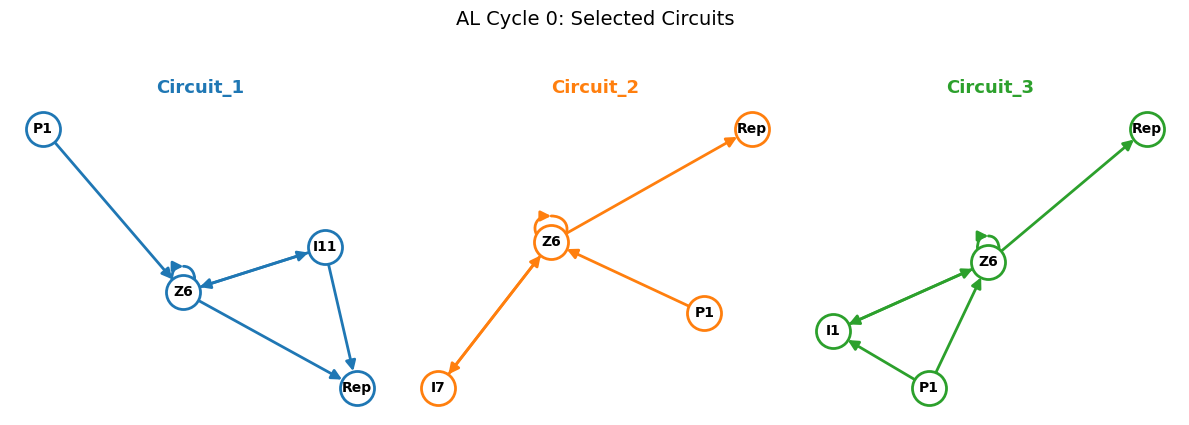


[AL Engine] Initialization Complete. Dynamic Targets Identified: {'I11': [0], 'I1': [0], 'Z6': [0, 1, 2], 'I7': [0]}

 🚀 STARTING AL CYCLE 0


[Designer] Simulating Grid: 100%|██████████| 30/30 [00:37<00:00,  1.24s/exp]


[Designer] Selected Experiments: [('Circuit_2', 3.8), ('Circuit_2', 3.4), ('Circuit_3', 1.0), ('Circuit_3', 1.4)]

[Learner] Assessing 50 models against 4 experiments
[Learner] Selected top 10 candidates.
[Learner] Best Total NMSE: 7.4737e-02

 🚀 STARTING AL CYCLE 1


[Designer] Simulating Grid: 100%|██████████| 30/30 [00:41<00:00,  1.39s/exp]


[Designer] Selected Experiments: [('Circuit_2', 0.2), ('Circuit_2', 0.6), ('Circuit_1', 0.2), ('Circuit_1', 0.6)]

[Learner] Assessing 50 models against 4 experiments
[Learner] Selected top 10 candidates.
[Learner] Best Total NMSE: 4.0641e-01

 🚀 STARTING AL CYCLE 2


[Designer] Simulating Grid: 100%|██████████| 30/30 [00:42<00:00,  1.42s/exp]


[Designer] Selected Experiments: [('Circuit_2', 1.4), ('Circuit_2', 1.8), ('Circuit_3', 0.2), ('Circuit_3', 0.6)]

[Learner] Assessing 50 models against 4 experiments
[Learner] Selected top 10 candidates.
[Learner] Best Total NMSE: 1.2708e-01

🎉 ACTIVE LEARNING LOOP FINISHED.

🎯 FINAL DISCOVERED PARAMETERS vs HIDDEN TRUTH:
   I11:
      AL Found: [0.039725]
      Truth:    [0.027711]
   I1:
      AL Found: [0.033706]
      Truth:    [0.036]
   Z6:
      AL Found: [2.201500e-02 6.779423e+01 3.236400e-02]
      Truth:    [1.5000e-02 7.2500e+01 3.6537e-02]
   I7:
      AL Found: [0.022124]
      Truth:    [0.025]

📄 Run summary automatically saved to: run_logs/AL_Run_20260616_0357.txt

[GCAD] >> UPDATING GCAD LIBRARY:
   PART: I11
      Idx [0]: 0.0277  -->  0.0397  (+43.36%)
   PART: I1
      Idx [0]: 0.0360  -->  0.0337  (-6.37%)
   PART: Z6
      Idx [0]: 0.0215  -->  0.0220  (+2.18%)
      Idx [1]: 61.1755  -->  67.7942  (+10.82%)
      Idx [2]: 0.0365  -->  0.0324  (-11.42%)
   PART:

Evolving: 100%|██████████| 50/50 [02:09<00:00,  2.59s/gen, Max Prominence=24.80]



Saving results to pickle files...
Done! Results saved in c:\Users\KuangQi\Desktop\temp\ActiveLearning-GCAD\results\cycle_1
[GCAD] >> Evolution Saved to c:\Users\KuangQi\Desktop\temp\ActiveLearning-GCAD\results\cycle_1

[GCAD] >> Extracting Top 3 Architectures...


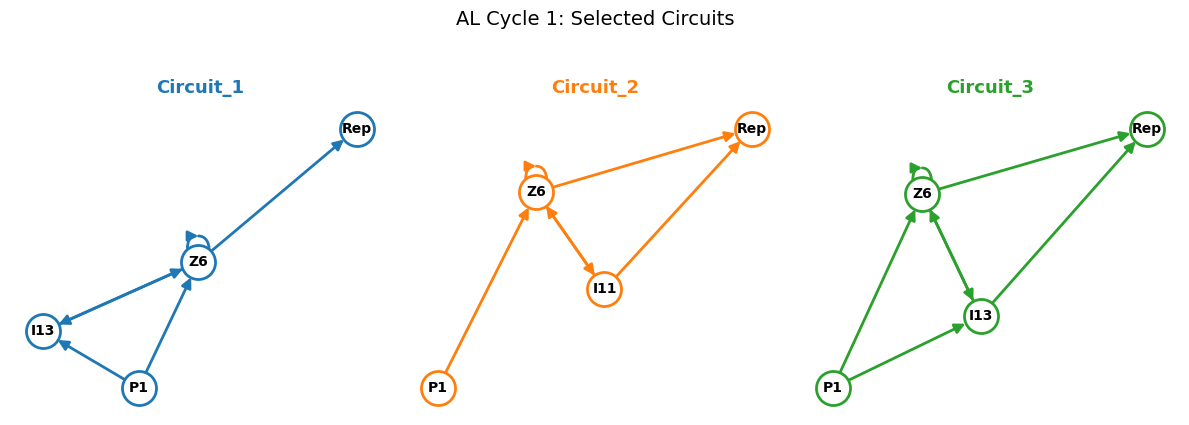


[AL Engine] Initialization Complete. Dynamic Targets Identified: {'I11': [0], 'I13': [0], 'Z6': [0, 1, 2]}

 🚀 STARTING AL CYCLE 0


[Designer] Simulating Grid: 100%|██████████| 30/30 [00:42<00:00,  1.41s/exp]


[Designer] Selected Experiments: [('Circuit_1', 1.0), ('Circuit_1', 0.6), ('Circuit_3', 0.2), ('Circuit_3', 0.6)]

[Learner] Assessing 50 models against 4 experiments
[Learner] Selected top 10 candidates.
[Learner] Best Total NMSE: 2.2179e-02

 🚀 STARTING AL CYCLE 1


[Designer] Simulating Grid: 100%|██████████| 30/30 [00:41<00:00,  1.39s/exp]


[Designer] Selected Experiments: [('Circuit_1', 3.8), ('Circuit_1', 3.4), ('Circuit_3', 3.0), ('Circuit_3', 3.4)]

[Learner] Assessing 50 models against 4 experiments
[Learner] Selected top 10 candidates.
[Learner] Best Total NMSE: 3.7218e-02

 🚀 STARTING AL CYCLE 2


[Designer] Simulating Grid: 100%|██████████| 30/30 [00:40<00:00,  1.34s/exp]


[Designer] Selected Experiments: [('Circuit_1', 3.8), ('Circuit_1', 3.4), ('Circuit_3', 1.8), ('Circuit_3', 1.4)]

[Learner] Assessing 50 models against 4 experiments
[Learner] Selected top 10 candidates.
[Learner] Best Total NMSE: 2.2982e-02

🎉 ACTIVE LEARNING LOOP FINISHED.

🎯 FINAL DISCOVERED PARAMETERS vs HIDDEN TRUTH:
   I11:
      AL Found: [0.07457]
      Truth:    [0.027711]
   I13:
      AL Found: [0.008081]
      Truth:    [0.009]
   Z6:
      AL Found: [1.8821000e-02 6.8407484e+01 3.2069000e-02]
      Truth:    [1.5000e-02 7.2500e+01 3.6537e-02]

📄 Run summary automatically saved to: run_logs/AL_Run_20260616_0402.txt

[GCAD] >> UPDATING GCAD LIBRARY:
   PART: I11
      Idx [0]: 0.0397  -->  0.0746  (+87.71%)
   PART: I13
      Idx [0]: 0.0116  -->  0.0081  (-30.09%)
   PART: Z6
      Idx [0]: 0.0220  -->  0.0188  (-14.51%)
      Idx [1]: 67.7942  -->  68.4075  (+0.90%)
      Idx [2]: 0.0324  -->  0.0321  (-0.91%)
[GCAD] Library updated. Ready for next cycle.


 AL CYCLE 2

[

Evolving: 100%|██████████| 50/50 [02:14<00:00,  2.69s/gen, Max Prominence=24.91]



Saving results to pickle files...
Done! Results saved in c:\Users\KuangQi\Desktop\temp\ActiveLearning-GCAD\results\cycle_2
[GCAD] >> Evolution Saved to c:\Users\KuangQi\Desktop\temp\ActiveLearning-GCAD\results\cycle_2

[GCAD] >> Extracting Top 3 Architectures...


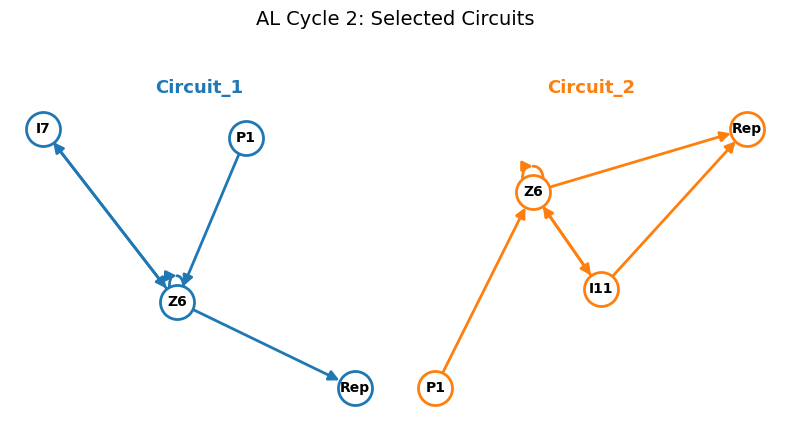


[AL Engine] Initialization Complete. Dynamic Targets Identified: {'I11': [0], 'Z6': [0, 1, 2], 'I7': [0]}

 🚀 STARTING AL CYCLE 0


[Designer] Simulating Grid: 100%|██████████| 20/20 [00:26<00:00,  1.34s/exp]


[Designer] Selected Experiments: [('Circuit_1', 2.6), ('Circuit_1', 3.4), ('Circuit_2', 0.2), ('Circuit_2', 0.6)]

[Learner] Assessing 50 models against 4 experiments
[Learner] Selected top 10 candidates.
[Learner] Best Total NMSE: 5.5887e-01

 🚀 STARTING AL CYCLE 1


[Designer] Simulating Grid: 100%|██████████| 20/20 [00:28<00:00,  1.41s/exp]


[Designer] Selected Experiments: [('Circuit_1', 0.6), ('Circuit_1', 1.0), ('Circuit_2', 0.2), ('Circuit_2', 0.6)]

[Learner] Assessing 50 models against 4 experiments
[Learner] Selected top 10 candidates.
[Learner] Best Total NMSE: 4.8260e-01

 🚀 STARTING AL CYCLE 2


[Designer] Simulating Grid: 100%|██████████| 20/20 [00:31<00:00,  1.56s/exp]


[Designer] Selected Experiments: [('Circuit_1', 0.2), ('Circuit_1', 0.6), ('Circuit_2', 0.2), ('Circuit_2', 0.6)]

[Learner] Assessing 50 models against 4 experiments
[Learner] Selected top 10 candidates.
[Learner] Best Total NMSE: 4.4150e-01

🎉 ACTIVE LEARNING LOOP FINISHED.

🎯 FINAL DISCOVERED PARAMETERS vs HIDDEN TRUTH:
   I11:
      AL Found: [0.041984]
      Truth:    [0.027711]
   Z6:
      AL Found: [1.6212000e-02 6.7428897e+01 3.4231000e-02]
      Truth:    [1.5000e-02 7.2500e+01 3.6537e-02]
   I7:
      AL Found: [0.023898]
      Truth:    [0.025]

📄 Run summary automatically saved to: run_logs/AL_Run_20260616_0406.txt

[GCAD] >> UPDATING GCAD LIBRARY:
   PART: I11
      Idx [0]: 0.0746  -->  0.0420  (-43.70%)
   PART: Z6
      Idx [0]: 0.0188  -->  0.0162  (-13.86%)
      Idx [1]: 68.4075  -->  67.4289  (-1.43%)
      Idx [2]: 0.0321  -->  0.0342  (+6.74%)
   PART: I7
      Idx [0]: 0.0221  -->  0.0239  (+8.02%)
[GCAD] Library updated. Ready for next cycle.

ALL AL CYCLES FIN

In [5]:
MAX_AL_CYCLES = 3
gcad_settings_path = os.path.abspath(os.path.join("data", "gcad_results", "FreeSearch_settings.json"))
results_base_dir = os.path.abspath("results")

for al_cycle in range(MAX_AL_CYCLES):
    print(f"\n\n{'='*40}")
    print(f" AL CYCLE {al_cycle}")
    print(f"{'='*40}")

    # Step A: GCAD discovers circuit architectures
    cycle_folder = os.path.join(results_base_dir, f"cycle_{al_cycle}")
    run_gcad_miner(gcad_settings_path, cycle_folder)

    # Step B: Extract top circuits and visualize
    my_circuits = extract_top_circuits(cycle_folder, m_target=3)
    draw_circuit(my_circuits, al_cycle)

    # Step C: AL calibrates kinetic parameters
    engine = ActiveLearningLoop(my_circuits, hidden_truth, config)
    calibrated_parts, _ = engine.run()

    # Step D: Update GCAD library for the next cycle
    update_gcad_library(calibrated_parts)

print("\nALL AL CYCLES FINISHED.")